In [29]:
import ROOT
import numpy as np
import math
import pandas as pd
import fastjet
import matplotlib.pyplot as plt


In [30]:
import uproot

In [31]:
#from preliminary file

f = ROOT.TFile.Open("/Users/rohanjagadeesan/Desktop/Code/li_lab/WinnerTakeAll/parton_data.root")
tree = f.Get("trackTree") 

jet_radius = 0.8 # max accepted by fastjet is 1000. radius value in prl paper is 0.8

wta_def = fastjet.JetDefinition(fastjet.antikt_algorithm, jet_radius, fastjet.WTA_pt_scheme) #wta definition
std_def = fastjet.JetDefinition(fastjet.antikt_algorithm, jet_radius) #standard E scheme definition

In [32]:
#modified from Xiao's code
#clarify what the criteria is - he had something about 200 that i have not included


def eventPass(jetPt, jetEta):  
    '''
    criteria for jet selection
    
    inputs:
        - jetEta: the jet's pseudorapidity, a positive or negative float
        - jetPt: the jet's momentum in GeV, a positive float             !!! USING STANDARD PT FOR CRITERIA, maybe later can try out with wta pt selection

    output: true if passed, false otherwise
    '''
    jetEtaCut = 1.6 #from PRL paper page 2
    jetPtCut = 550 #from prl paper,         STANDARD pt, not WTA

    if(abs(jetEta)>jetEtaCut): return False
    if(jetPt < jetPtCut): return False

    return True


def particlePass(particlePt, particleEta, particleCharge):
    '''
    criteria for particle selection

    inputs: 
        - particlePt: positive float for particle momentum magnitude
        - particleEta: float (positive or negative) for particle pseudorapidity
        - particleCharge: the particle's charge, not sure about the variable type

    output: true if passed, false otherwise
    '''
    particlePtCut = 0.3 #from prl paper page 2
    particleEtaCut = 2.4 #from prl paper page 2
    
    if(particlePt < particlePtCut): return False
    if(abs(particleEta) > particleEtaCut): return False

    if (particleCharge is None or particleCharge==0): return False #only accepting charged particles

    return True



In [33]:
#from prelim file

def make_pseudojets(pts, etas, phis, charges):
    '''
    converts particles of one jet to a list of pseudojets. particle quality cuts are built in.
    inputs:
        - pts: a vector of particles for a given jet
        - etas: the corresponding pseudorapidities for each particle in the jet
        - phis: the corresponding azimuthal angles for each particle in the jet
        - charges: the charges of each particle in the jet
        
    output:
        - pj_list: a list of pseudojets, each pseudojet represents a particle in the jet
    '''
    
    pj_list = []

    for i in range(len(pts)): #looping through each particle in the jet
        
        if particlePass(pts[i], etas[i], charges[i]): #particle selection criteria
            p = fastjet.PseudoJet() #initialising a pseudojet
            p.reset_PtYPhiM(pts[i], etas[i], phis[i], 0.0) #defining the i-th particle as a pseudojet
            pj_list.append(p) #adding the particle to the list of pseudojets
    
    return pj_list #list of pseudojets


In [ ]:
#transforming values to jet frame

def particleToJetFrame(jet_px, jet_py, jet_pz, particle):
    """
    Transforms one constituent particle to the jet frame.
    
    Inputs:
        - jet_px, jet_py, jet_pz: The lab frame cartesian momentum 3-vector for the WHOLE jet
        - particle: A lab frame pseudoJet CONSTITUENT of that jet

    output:
        - jt: jet frame transverse momentum of the particle
        - eta_star: jet frame pseudorapidity of the particle
        - phi_star: jet frame phi of the particle
        - onAxis: 0 if not on z axis, 1 if on +z, -1 if on -z
    """

    # 1. Convert to ROOT TVector3
    # Use px, py, pz to ensure we have the full 3D vector
    p_jet = ROOT.TVector3(jet_px, jet_py, jet_pz)                 #momentum 3-vector of the whole jet
    p_part = ROOT.TVector3(particle.px(), particle.py(), particle.pz()) #momentum 3-vector of the particle

    # 1. Calculate Eta star (Relative Eta), discard non-qualifiers
    theta = p_part.Angle(p_jet)     #dot product angle between particle and jet momenta, range 0 to pi
    #cases for theta
    onAxis = 0
    if theta == 0:
        onAxis = 1
        eta_star = 999
    elif theta == math.pi:
        onAxis = -1
        eta_star = -999
    else: 
        eta_star = -math.log(math.tan(theta / 2.0)) #pseudorapidity formula for acceptable theta
        

    # 2. Calculate jT (Relative pT)
    jt = p_part.Perp(p_jet) #magnitude of part of particle momentum that is perpendicular to jet momentum

    # 4. Calculate Phi star (Relative Phi)
    unit_jet = p_jet.Unit()
    z_axis = ROOT.TVector3(0, 0, 1)
    
    # Vector purely transverse to the jet axis
    v_pt = p_part - (unit_jet * p_part.Dot(unit_jet)) #magnitude of this is jt
    
    # Define the reference plane (jet axis & beam line)
    phi_origin = unit_jet.Cross(unit_jet.Cross(z_axis)) #phi = 0 vector, taken from Xiao's code
    
    phi_star = v_pt.Angle(phi_origin)
    
    # Determine the sign of phi_star
    if (phi_origin.Cross(v_pt.Unit())).Dot(unit_jet) < 0:
        phi_star =  -phi_star

    return jt, eta_star, phi_star, onAxis


def jetToJetFrame(labFrame_pj):
    '''
    transforms all constituents of a full jet from lab frame to the jet frame

    input: lab_pj, a jet pseudojet with coordinates measured in lab frame. The jet should already be clustered according to the desired scheme.

    output: ple_pj_list, a list of particle pseudojets with coordinates measured in the jet frame. 
    '''
    #Extracting px, py, pz of the whole jet in lab frame
    jet_px =  labFrame_pj.px()
    jet_py = labFrame_pj.py()
    jet_pz = labFrame_pj.pz()
    
    ple_pj_list = [] #initialising list of particle pseudojets

    #looping through constituents
    jet_constituents = labFrame_pj.constituents()
    for particle in jet_constituents:
        
        #finding jet frame coordinates for the particle
        jetFrame_pt, jetFrame_eta, jetFrame_phi, onAxis = particleToJetFrame(jet_px, jet_py, jet_pz, particle)

        p_in = fastjet.PseudoJet() #initialising a pseudojet
        #reset p_in appropriately (on or off z axis) to avoid infinite pz and E
        if onAxis == 0: #not on the axis
            p_in.reset_PtYPhiM(jetFrame_pt, jetFrame_eta, jetFrame_phi, 0.0) #redefining the particle in the jet frame (last index is mass)   
        elif onAxis == 1: #on +z axis
            p_in.reset(0, 0, particle.modp(), particle.E())   #all momentum is in pz
        elif onAxis == -1: #on -z axis
            p_in.reset(0, 0, -particle.modp(), particle.E())
        
        ple_pj_list.append(p_in) #add the newly defined particle pseudojet to the list

    return ple_pj_list


In [ ]:
# do the 2 particle correlation
#simplified version rn for testing
def build2pc(pj_list, index):
    '''
    builds the 2 particle correlator 
    
    input: pj_list, a list of particle pseudojets for one jet. these should be in the jet frame
    
    output:
        info_list, a list of correlator info dictionaries
    '''

    multiplicity = len(pj_list) 
    info_list = [] #initialise the list

    for i in range(multiplicity-1):
        for j in range(i+1, multiplicity): 
            delta_eta_star = pj_list[i].eta() - pj_list[j].eta()
            delta_phi_star = ROOT.TVector2.Phi_mpi_pi(pj_list[i].phi() - pj_list[j].phi())  
            dR = math.sqrt(delta_eta_star**2 + delta_phi_star**2)
            
            info_for_2pc = {
                    "dEta": delta_eta_star,
                    "dPhi": delta_phi_star,
                    "dR": dR,
                    "multiplicity": multiplicity, #number of valid charged particles in the jet
                    "jet index": index
                    #add pair energy and jet energy later for EEC
                }
            
            info_list.append(info_for_2pc)
    

    return info_list

In [67]:
wta_correlation_data = [] #list of dictionaries
std_correlation_data = []
jet_index = (-1,-1) #event num, jet num

loopcount = 0 #for testing the loop
# main event loop, creating the data for each jet
for event in tree:
    loopcount+=1 #for testing
    if loopcount>10000:
        break
    
    jet_index = (jet_index[0]+1, -1)
    # 1. Loop over jets in the event
    for ijet in range(event.genJetPt.size()):
        jet_index = (jet_index[0], jet_index[1]+1)
        
        #extracting standard pt and eta from ROOT data for cuts
        std_pt = event.genJetPt[ijet]
        std_eta = event.genJetEta[ijet]
        
        if eventPass(std_pt, std_eta): #event cut using STANDARD pt and eta

            # 2. Get the daughter vectors for ONLY this jet
            dau_pts = event.genDau_pt[ijet]
            dau_etas = event.genDau_eta[ijet]
            dau_phis = event.genDau_phi[ijet]
            dau_charges = event.genDau_chg[ijet]

            # 3. Create PseudoJets for this specific jet
            jet_constituents = make_pseudojets(dau_pts, dau_etas, dau_phis, dau_charges)    #cuts are built in

            # 4. Cluster with WTA and standard to find the new axis
            wta_clustered = fastjet.ClusterSequence(jet_constituents, wta_def)          #this is a cluster sequence, can't be directly queried for momentum, etc.
            wta_jets_tup = fastjet.sorted_by_pt(wta_clustered.inclusive_jets())         #just one jet but it's a tuple so we need 0th index

            std_clustered = fastjet.ClusterSequence(jet_constituents, std_def)          #cluster sequence again
            std_jets_tup = fastjet.sorted_by_pt(std_clustered.inclusive_jets())         #tuple again
            

            if len(wta_jets_tup) > 0: #preventing indexing errors
                wta_jet = wta_jets_tup[0]   #indexing to get the actual pseudojet we can query
                std_jet = std_jets_tup[0]
                
                # 5. shifting to jet frame
                wta_in_jet_frame = jetToJetFrame(wta_jet) #list of particle pseudojets in the jet frame
                std_in_jet_frame = jetToJetFrame(std_jet)

                
                # Save all the useful info for this specific jet in a dictionary
                wta_jet_info = build2pc(wta_in_jet_frame, jet_index)
                std_jet_info = build2pc(std_in_jet_frame, jet_index)
                
                # Add to our main list of jets
                wta_correlation_data.extend(wta_jet_info)
                std_correlation_data.extend(std_jet_info)


wta_df = pd.DataFrame(wta_correlation_data)
std_df = pd.DataFrame(std_correlation_data)

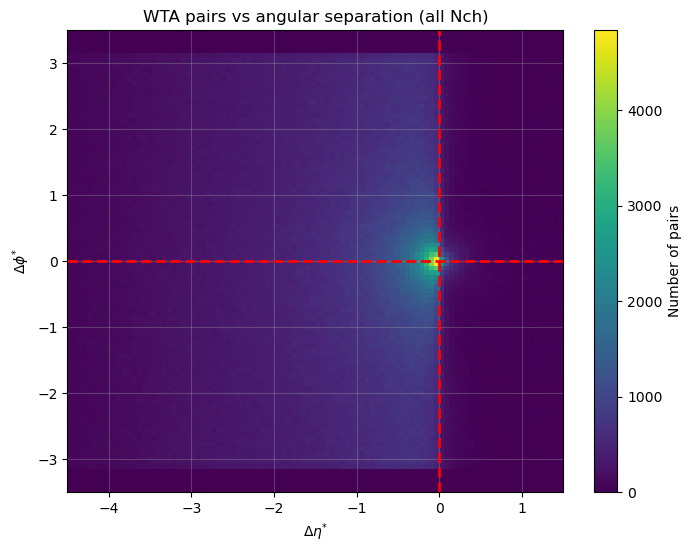

In [81]:
#number of pairs vs dEta and dPhi

plt.figure(figsize=(8, 6))

# 2. Create the 2D Histogram
h = plt.hist2d(wta_df['dEta'], wta_df['dPhi'], 
               bins=(100, 100), 
               range=[[-4.5, 1.5], [-3.5, 3.5]],                   
               cmap='viridis', 
               #cmin=1
               )

# 3. Add a colorbar to show what the colors mean (density of jets)
plt.colorbar(h[3], label='Number of pairs')

# 4. Add a horizontal reference line
plt.axhline(0.0, color='red', linestyle='dashed', linewidth=2)
plt.axvline(0.0, color='red', linestyle='dashed', linewidth=2)

# 5. Labels and styling
plt.title('WTA pairs vs angular separation (all Nch)')
plt.xlabel(r'$\Delta \eta ^{*}$')
plt.ylabel(r'$\Delta \phi ^{*}$')
plt.grid(True, alpha=0.3)

plt.show()


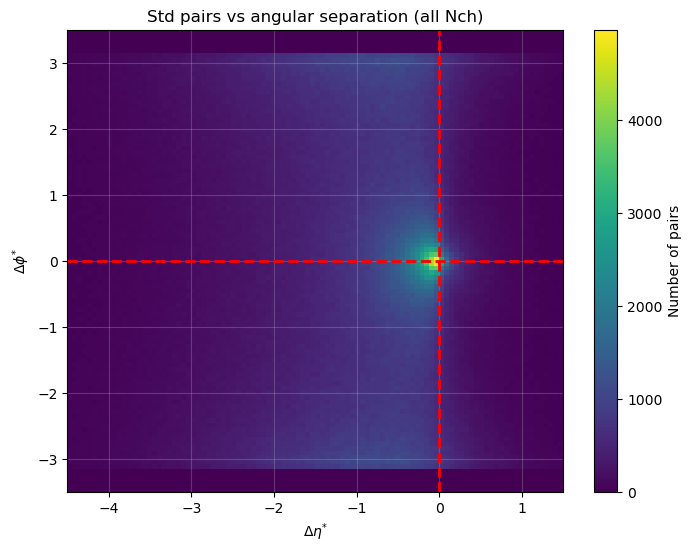

In [82]:
#number of pairs vs dEta and dPhi

plt.figure(figsize=(8, 6))

# 2. Create the 2D Histogram
h = plt.hist2d(std_df['dEta'], std_df['dPhi'], 
               bins=(100, 100), 
               range=[[-4.5, 1.5], [-3.5, 3.5]],                   
               cmap='viridis', 
               #cmin=1
               )

# 3. Add a colorbar to show what the colors mean (density of jets)
plt.colorbar(h[3], label='Number of pairs')

# 4. Add a horizontal reference line
plt.axhline(0.0, color='red', linestyle='dashed', linewidth=2)
plt.axvline(0.0, color='red', linestyle='dashed', linewidth=2)

# 5. Labels and styling
plt.title('Std pairs vs angular separation (all Nch)')
plt.xlabel(r'$\Delta \eta ^{*}$')
plt.ylabel(r'$\Delta \phi ^{*}$')
plt.grid(True, alpha=0.3)

plt.show()


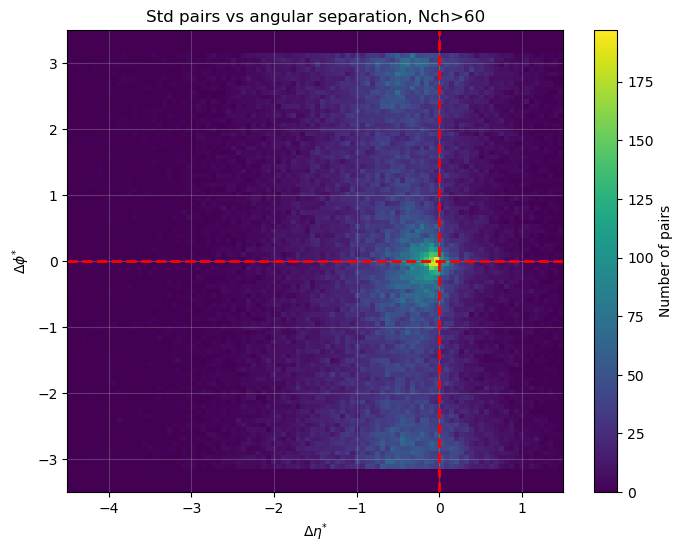

In [83]:
#number of pairs vs dEta and dPhi

plt.figure(figsize=(8, 6))

mult_bin = std_df[std_df['multiplicity']>60]

# 2. Create the 2D Histogram
h = plt.hist2d(mult_bin['dEta'], mult_bin['dPhi'], 
               bins=(100, 100), 
               range=[[-4.5, 1.5], [-3.5, 3.5]],                   
               cmap='viridis', 
               #cmin=1
               )

# 3. Add a colorbar to show what the colors mean (density of jets)
plt.colorbar(h[3], label='Number of pairs')

# 4. Add a horizontal reference line
plt.axhline(0.0, color='red', linestyle='dashed', linewidth=2)
plt.axvline(0.0, color='red', linestyle='dashed', linewidth=2)

# 5. Labels and styling
plt.title('Std pairs vs angular separation, Nch>60')
plt.xlabel(r'$\Delta \eta ^{*}$')
plt.ylabel(r'$\Delta \phi ^{*}$')
plt.grid(True, alpha=0.3)

plt.show()

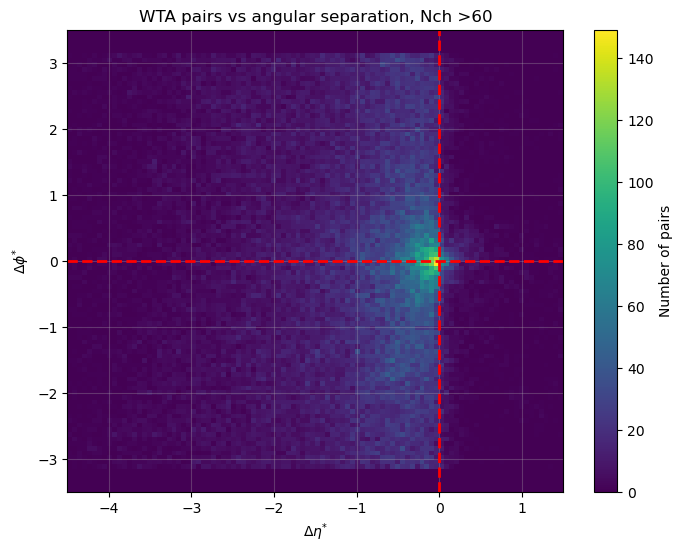

In [84]:
#number of pairs vs dEta and dPhi

plt.figure(figsize=(8, 6))

mult_bin = wta_df[wta_df['multiplicity']>60]

# 2. Create the 2D Histogram
h = plt.hist2d(mult_bin['dEta'], mult_bin['dPhi'], 
               bins=(100, 100), 
               range=[[-4.5, 1.5], [-3.5, 3.5]],                   
               cmap='viridis', 
               #cmin=1
               )

# 3. Add a colorbar to show what the colors mean 
plt.colorbar(h[3], label='Number of pairs')

# 4. Add a horizontal reference line
plt.axhline(0.0, color='red', linestyle='dashed', linewidth=2)
plt.axvline(0.0, color='red', linestyle='dashed', linewidth=2)

# 5. Labels and styling
plt.title(r'WTA pairs vs angular separation, Nch >60')
plt.xlabel(r'$\Delta \eta ^{*}$')
plt.ylabel(r'$\Delta \phi ^{*}$')
plt.grid(True, alpha=0.3)

plt.show()

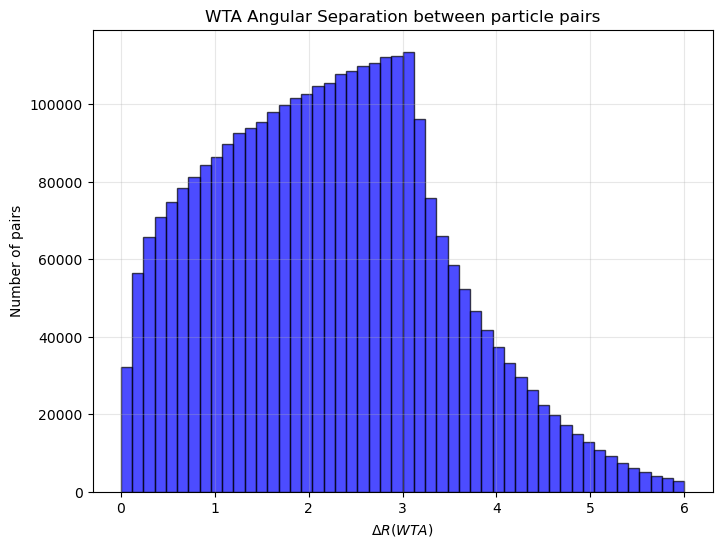

In [85]:
#number of pairs for a given dR

plt.figure(figsize=(8, 6))

# Plot a histogram of the dR column
plt.hist(wta_df['dR'], bins=50, range=(0, 6), color='blue', alpha=0.7, edgecolor='black') #standard jet radius is 0.5

plt.title('WTA Angular Separation between particle pairs')
plt.xlabel(r'$\Delta R(WTA)$')
plt.ylabel('Number of pairs')
#plt.yscale('log') # Log scale is standard for this distribution
plt.grid(True, alpha=0.3)
plt.show()

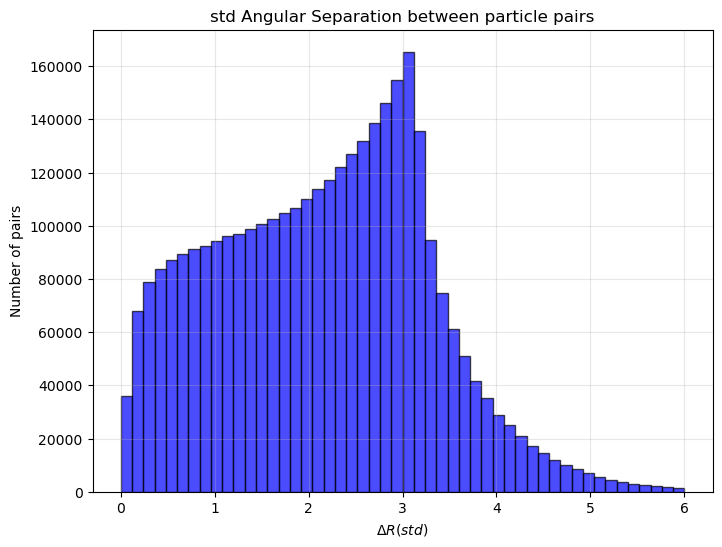

In [86]:
#number of pairs for a given dR

plt.figure(figsize=(8, 6))

# Plot a histogram of the dR column
plt.hist(std_df['dR'], bins=50, range=(0, 6), color='blue', alpha=0.7, edgecolor='black') #standard jet radius is 0.5

plt.title('std Angular Separation between particle pairs')
plt.xlabel(r'$\Delta R(std)$')
plt.ylabel('Number of pairs')
#plt.yscale('log') # Log scale is standard for this distribution
plt.grid(True, alpha=0.3)
plt.show()